# Graph-Aware Denoiser for TabDDPM — Full Workflow

This notebook walks through the complete pipeline of the **graph-aware denoiser** extension to TabDDPM:

1. Dataset exploration  
2. Building and visualising the static feature-dependency graph  
3. Training `GraphAwareDenoiser` (static and dynamic modes)  
4. Sampling synthetic data  
5. Evaluating quality vs. real data  
6. Side-by-side comparison with the vanilla `MLPDiffusion` baseline  

**Dataset used**: `cardio` — 5 numerical features, 6 categorical features, binary classification.  
All cells run from the repository root and require no external data download.

## 0 · Environment setup

In [35]:
import sys, os

# Make sure scripts/ and the project root are on the path
ROOT = os.path.abspath(".")
SCRIPTS = os.path.join(ROOT, "scripts")
for p in [ROOT, SCRIPTS]:
    if p not in sys.path:
        sys.path.insert(0, p)

import warnings
warnings.filterwarnings("ignore")

import math
from copy import deepcopy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import zero

# TabDDPM core
import lib
from tab_ddpm import GaussianMultinomialDiffusion
from tab_ddpm.modules import MLPDiffusion
from tab_ddpm.graph_builder import build_static_adjacency, DynamicAdjacency
from tab_ddpm.graph_denoiser import GraphAwareDenoiser

# Training utilities
from utils_train import get_model, make_dataset, update_ema

sns.set_theme(style="whitegrid", palette="muted")
DEVICE = torch.device("cpu")   # change to "cuda:0" if available
SEED   = 0
zero.improve_reproducibility(SEED)
print("PyTorch:", torch.__version__, "| Device:", DEVICE)

PyTorch: 1.13.1 | Device: cpu


## 1 · Dataset exploration

In [38]:
DATA_PATH = "data/adult"

from sklearn.preprocessing import OrdinalEncoder

X_num_raw  = np.load(f"{DATA_PATH}/X_num_train.npy").astype(np.float32)
_X_cat_raw = np.load(f"{DATA_PATH}/X_cat_train.npy", allow_pickle=True)
if _X_cat_raw.dtype.kind in ('U', 'S', 'O'):   # string array
    _cat_enc  = OrdinalEncoder(dtype=np.float64)
    X_cat_raw = _cat_enc.fit_transform(_X_cat_raw).astype(np.int64)
else:
    _cat_enc  = None
    X_cat_raw = _X_cat_raw.astype(np.int64)
y_raw = np.load(f"{DATA_PATH}/y_train.npy")

D_NUM  = X_num_raw.shape[1]   # 5
N_CAT  = X_cat_raw.shape[1]   # 6
CAT_SIZES = [int(X_cat_raw[:, i].max()) + 1 for i in range(N_CAT)]

print(f"Train rows  : {X_num_raw.shape[0]:,}")
print(f"Numerical   : {D_NUM} features")
print(f"Categorical : {N_CAT} features  sizes={CAT_SIZES}")
print(f"Label dist  : {dict(zip(*np.unique(y_raw, return_counts=True)))}")
print(f"Graph nodes : N = {D_NUM + N_CAT}")

Train rows  : 26,048
Numerical   : 6 features
Categorical : 8 features  sizes=[9, 16, 7, 15, 6, 5, 2, 42]
Label dist  : {0: 19775, 1: 6273}
Graph nodes : N = 14


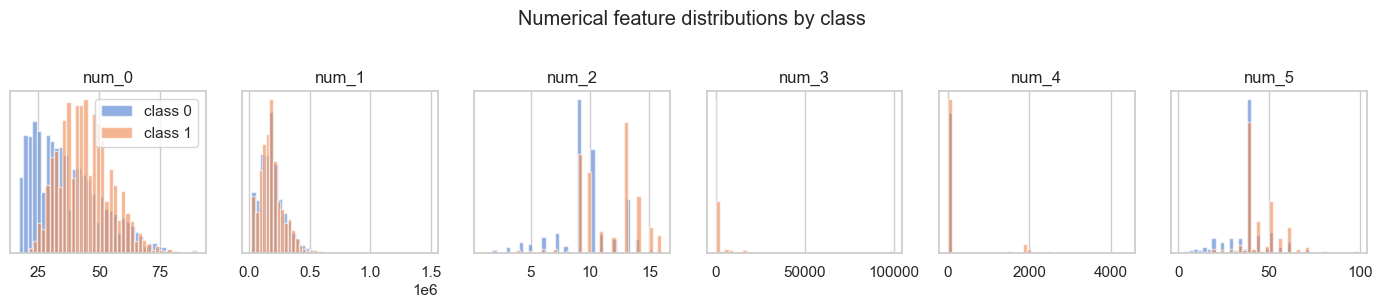

In [39]:
# Distribution of numerical features split by label
NUM_NAMES = [f"num_{i}" for i in range(D_NUM)]
CAT_NAMES = [f"cat_{i}" for i in range(N_CAT)]
NODE_NAMES = NUM_NAMES + CAT_NAMES

df_num = pd.DataFrame(X_num_raw, columns=NUM_NAMES)
df_num["label"] = y_raw

fig, axes = plt.subplots(1, D_NUM, figsize=(14, 3))
for i, col in enumerate(NUM_NAMES):
    for lbl in [0, 1]:
        axes[i].hist(df_num.loc[df_num.label == lbl, col], bins=40,
                     alpha=0.6, label=f"class {lbl}", density=True)
    axes[i].set_title(col)
    axes[i].set_yticks([])
axes[0].legend()
fig.suptitle("Numerical feature distributions by class", y=1.02)
plt.tight_layout()
plt.show()

## 2 · Build and visualise the static feature-dependency graph

In [40]:
THRESHOLD = 0.1

adj = build_static_adjacency(
    X_num=X_num_raw,
    X_cat=X_cat_raw,
    d_num=D_NUM,
    cat_sizes=CAT_SIZES,
    threshold=THRESHOLD,
)

N = adj.shape[0]
n_self  = N
n_edges = int(adj.sum().item()) - n_self
density = n_edges / max(N * (N - 1), 1)

print(f"Nodes   : {N}  ({D_NUM} numerical + {N_CAT} categorical)")
print(f"Edges   : {n_edges} off-diagonal  (threshold={THRESHOLD})")
print(f"Density : {density:.3f}")

Nodes   : 14  (6 numerical + 8 categorical)
Edges   : 42 off-diagonal  (threshold=0.1)
Density : 0.231


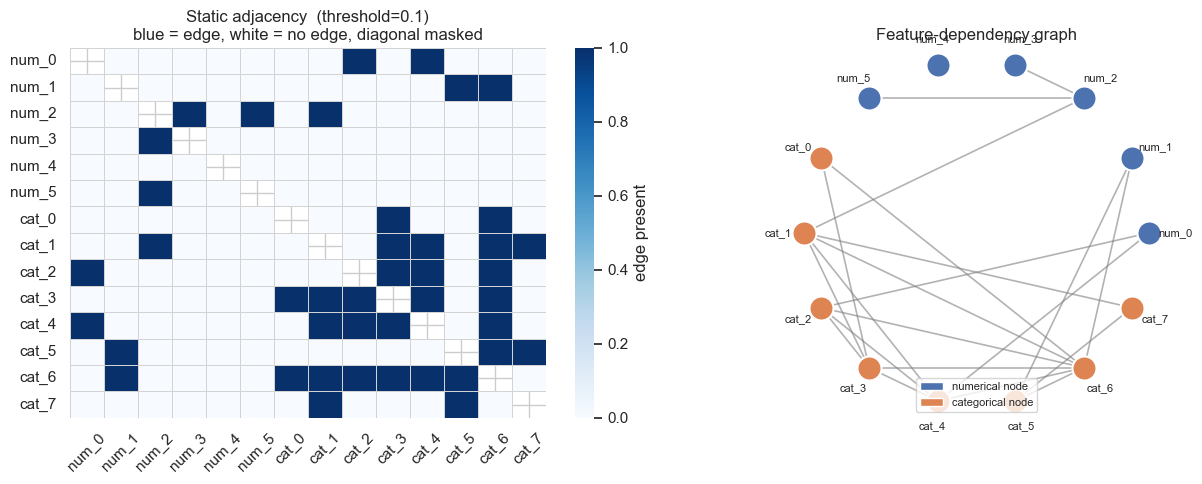

In [41]:
# Adjacency heatmap + graph drawing side-by-side
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: heatmap ---
mask = torch.eye(N).bool()   # mask self-loops so diagonal doesn't dominate colour
adj_no_self = adj.clone()
adj_no_self[mask] = float("nan")

sns.heatmap(
    adj_no_self.numpy(), ax=axes[0],
    cmap="Blues", vmin=0, vmax=1,
    xticklabels=NODE_NAMES, yticklabels=NODE_NAMES,
    linewidths=0.4, linecolor="lightgrey",
    cbar_kws={"label": "edge present"},
)
axes[0].set_title(f"Static adjacency  (threshold={THRESHOLD})\nblue = edge, white = no edge, diagonal masked")
axes[0].tick_params(axis="x", rotation=45)

# --- Right: graph drawing with matplotlib (no networkx needed) ---
ax = axes[1]
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("Feature-dependency graph")

angles = [2 * math.pi * i / N for i in range(N)]
pos = {i: (math.cos(a), math.sin(a)) for i, a in enumerate(angles)}
colors = ["#4C72B0"] * D_NUM + ["#DD8452"] * N_CAT   # blue=num, orange=cat

# Draw edges
drawn = set()
for i in range(N):
    for j in range(i + 1, N):
        if adj[i, j] > 0:
            xi, yi = pos[i]; xj, yj = pos[j]
            ax.plot([xi, xj], [yi, yj], color="grey", linewidth=1.2,
                    alpha=0.6, zorder=1)

# Draw nodes
for i in range(N):
    xi, yi = pos[i]
    ax.scatter(xi, yi, s=300, color=colors[i], zorder=3, edgecolors="white",
               linewidths=1.5)
    offset = 0.15
    ax.text(xi * (1 + offset), yi * (1 + offset), NODE_NAMES[i],
            ha="center", va="center", fontsize=8)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#4C72B0", label="numerical node"),
                   Patch(facecolor="#DD8452", label="categorical node")]
ax.legend(handles=legend_elements, loc="lower center", fontsize=8)

plt.tight_layout()
plt.show()

## 3 · Prepare data for training

We use TabDDPM's standard preprocessing pipeline (`Transformations` + `make_dataset`)
so the denoiser sees normalised numericals and properly encoded categoricals —
the same preprocessing the original `MLPDiffusion` receives.

In [30]:
T_DICT = dict(
    seed=SEED,
    normalization="quantile",
    num_nan_policy=None,
    cat_nan_policy=None,
    cat_min_frequency=None,
    cat_encoding=None,
    y_policy="default",
)
NUM_CLASSES = 2
IS_Y_COND   = True

T = lib.Transformations(**T_DICT)
dataset = make_dataset(DATA_PATH, T, num_classes=NUM_CLASSES, is_y_cond=IS_Y_COND, change_val=False)

K = np.array(dataset.get_category_sizes("train"))
if len(K) == 0 or T_DICT["cat_encoding"] == "one-hot":
    K = np.array([0])

d_num_pp  = dataset.X_num["train"].shape[1] if dataset.X_num is not None else 0
d_in      = int(np.sum(K)) + d_num_pp
cat_sizes_pp = [int(k) for k in dataset.get_category_sizes("train") if k > 0]

print(f"d_num (post-preprocessing) : {d_num_pp}")
print(f"K (diffusion cat slots)    : {K}")
print(f"cat_sizes for graph        : {cat_sizes_pp}")
print(f"d_in (denoiser input dim)  : {d_in}")

train_loader = lib.prepare_fast_dataloader(dataset, split="train", batch_size=4096)

d_num (post-preprocessing) : 5
K (diffusion cat slots)    : [2 3 3 2 2 2]
cat_sizes for graph        : [2, 3, 3, 2, 2, 2]
d_in (denoiser input dim)  : 19


## 4 · Build the static adjacency on the preprocessed training split

The adjacency is built **only on the training split** to avoid data leakage.
`dataset.X_num["train"]` and `dataset.X_cat["train"]` are already quantile-normalised /
encoded, which is the correct input for the statistical measures.

In [7]:
adj_train = build_static_adjacency(
    X_num      = dataset.X_num["train"] if dataset.X_num is not None else None,
    X_cat      = dataset.X_cat["train"] if dataset.X_cat is not None else None,
    d_num      = d_num_pp,
    cat_sizes  = cat_sizes_pp,
    threshold  = 0.1,
)

n_off = int(adj_train.sum().item()) - adj_train.shape[0]
print(f"Adjacency shape : {tuple(adj_train.shape)}")
print(f"Off-diag edges  : {n_off}  (density {n_off / max(adj_train.shape[0]*(adj_train.shape[0]-1),1):.3f})")

Adjacency shape : (11, 11)
Off-diag edges  : 22  (density 0.200)


## 5 · Instantiate `GraphAwareDenoiser`

In [8]:
GRAPH_PARAMS = dict(
    d_model  = 64,   # 128 for production runs
    n_layers = 2,    # 4   for production runs
    n_heads  = 4,
    top_k    = 0,
)

denoiser_graph = GraphAwareDenoiser(
    d_in        = d_in,
    num_classes = NUM_CLASSES,
    is_y_cond   = IS_Y_COND,
    d_num       = d_num_pp,
    cat_sizes   = cat_sizes_pp,
    graph_mode  = "static",
    adjacency   = adj_train,
    **GRAPH_PARAMS,
).to(DEVICE)

n_params = sum(p.numel() for p in denoiser_graph.parameters())
print(f"GraphAwareDenoiser  ({n_params:,} parameters)")
print(f"  nodes  : {denoiser_graph.N}")
print(f"  layers : {len(denoiser_graph.layers)}")
print(f"  d_model: {denoiser_graph.d_model}")

GraphAwareDenoiser  (128,019 parameters)
  nodes  : 11
  layers : 2
  d_model: 64


## 6 · Training loop

We wrap the denoiser in `GaussianMultinomialDiffusion` — the same diffusion
process used by the original TabDDPM — and run a standard AdamW training loop
with linear LR annealing and EMA weight tracking.

In [9]:
def run_training(denoiser, train_loader, steps=2000, lr=1e-3, weight_decay=1e-5,
                 log_every=200, device=DEVICE):
    """Train a denoiser inside GaussianMultinomialDiffusion and return
    (diffusion, ema_model, loss_history_df)."""
    diffusion = GaussianMultinomialDiffusion(
        num_classes            = K,
        num_numerical_features = d_num_pp,
        denoise_fn             = denoiser,
        gaussian_loss_type     = "mse",
        num_timesteps          = 1000,
        scheduler              = "cosine",
        device                 = device,
    ).to(device)
    diffusion.train()

    ema = deepcopy(denoiser)
    for p in ema.parameters():
        p.detach_()

    opt = torch.optim.AdamW(diffusion.parameters(), lr=lr, weight_decay=weight_decay)

    history = []
    curr_m = curr_g = curr_n = 0
    bar_width = 30

    print(f"{'Step':>10}  {'Progress':<{bar_width+2}}  {'M-Loss':>8}  {'G-Loss':>8}  {'Total':>8}")
    print("-" * (10 + bar_width + 34))

    for step in range(1, steps + 1):
        x, y_batch = next(train_loader)
        x = x.to(device)
        out_dict = {"y": y_batch.long().to(device)}

        opt.zero_grad()
        lm, lg = diffusion.mixed_loss(x, out_dict)
        loss = lm + lg
        loss.backward()
        opt.step()

        # Linear LR annealing
        for pg in opt.param_groups:
            pg["lr"] = lr * (1 - step / steps)

        curr_m += lm.item() * len(x)
        curr_g += lg.item() * len(x)
        curr_n += len(x)
        update_ema(ema.parameters(), diffusion._denoise_fn.parameters())

        if step % log_every == 0:
            ml = curr_m / curr_n
            gl = curr_g / curr_n
            history.append({"step": step, "mloss": ml, "gloss": gl, "loss": ml + gl})

            frac      = step / steps
            filled    = int(bar_width * frac)
            bar       = "█" * filled + "░" * (bar_width - filled)
            pct       = f"{frac*100:5.1f}%"
            print(f"{step:>5}/{steps:<5}  [{bar}] {pct}  {ml:>8.4f}  {gl:>8.4f}  {ml+gl:>8.4f}")

            curr_m = curr_g = curr_n = 0

    print("-" * (10 + bar_width + 34))
    print("Training complete.\n")
    return diffusion, ema, pd.DataFrame(history)

In [12]:
STEPS = 1000   # fast exploration; use 5000–10000 for production runs

print("=== Training GraphAwareDenoiser (static mode) ===")
diffusion_graph, ema_graph, hist_graph = run_training(
    denoiser_graph, train_loader, steps=STEPS
)

=== Training GraphAwareDenoiser (static mode) ===
      Step  Progress                            M-Loss    G-Loss     Total
--------------------------------------------------------------------------
  200/1000   [██████░░░░░░░░░░░░░░░░░░░░░░░░]  20.0%    0.6199    0.4805    1.1004
  400/1000   [████████████░░░░░░░░░░░░░░░░░░]  40.0%    0.5854    0.4575    1.0429
  600/1000   [██████████████████░░░░░░░░░░░░]  60.0%    0.5818    0.4443    1.0261
  800/1000   [████████████████████████░░░░░░]  80.0%    0.5779    0.4307    1.0085
 1000/1000   [██████████████████████████████] 100.0%    0.5701    0.4271    0.9972
--------------------------------------------------------------------------
Training complete.



## 7 · Train the baseline `MLPDiffusion` for comparison

In [11]:
denoiser_mlp = MLPDiffusion(
    d_in        = d_in,
    num_classes = NUM_CLASSES,
    is_y_cond   = IS_Y_COND,
    rtdl_params = dict(d_layers=[256, 256], dropout=0.0),
).to(DEVICE)

n_params_mlp = sum(p.numel() for p in denoiser_mlp.parameters())
print(f"MLPDiffusion ({n_params_mlp:,} parameters)")

print("\n=== Training MLPDiffusion (baseline) ===")
diffusion_mlp, ema_mlp, hist_mlp = run_training(
    denoiser_mlp, train_loader, steps=STEPS   # same STEPS as graph model
)

MLPDiffusion (139,539 parameters)

=== Training MLPDiffusion (baseline) ===
      Step  Progress                            M-Loss    G-Loss     Total
--------------------------------------------------------------------------
  200/1000   [██████░░░░░░░░░░░░░░░░░░░░░░░░]  20.0%    0.4773    1.1352    1.6125
  400/1000   [████████████░░░░░░░░░░░░░░░░░░]  40.0%    0.4451    0.6862    1.1313
  600/1000   [██████████████████░░░░░░░░░░░░]  60.0%    0.4404    0.5298    0.9702
  800/1000   [████████████████████████░░░░░░]  80.0%    0.4391    0.4957    0.9348
 1000/1000   [██████████████████████████████] 100.0%    0.4364    0.4840    0.9204
--------------------------------------------------------------------------
Training complete.



## 8 · Training curves

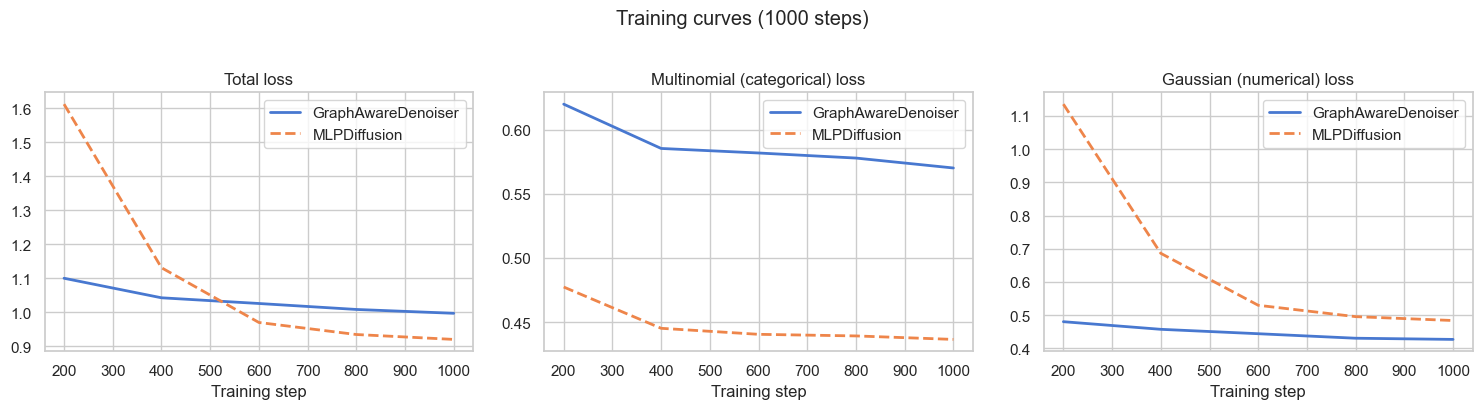

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
titles = ["Total loss", "Multinomial (categorical) loss", "Gaussian (numerical) loss"]
cols   = ["loss", "mloss", "gloss"]

for ax, col, title in zip(axes, cols, titles):
    ax.plot(hist_graph["step"], hist_graph[col], label="GraphAwareDenoiser", linewidth=2)
    ax.plot(hist_mlp["step"],   hist_mlp[col],   label="MLPDiffusion",       linewidth=2,
            linestyle="--")
    ax.set_xlabel("Training step")
    ax.set_title(title)
    ax.legend()

fig.suptitle(f"Training curves ({STEPS} steps)", y=1.02)
plt.tight_layout()
plt.show()

## 9 · Sample synthetic data

We use the **EMA weights** (more stable generation quality) and generate the
same number of rows as the training set.

In [15]:
def sample_synthetic(diffusion, ema_denoiser, n_samples=10000,
                      batch_size=2000, device=DEVICE):
    """Swap in EMA weights, set eval mode, run reverse diffusion."""
    diffusion._denoise_fn.load_state_dict(ema_denoiser.state_dict())
    diffusion.eval()

    _, emp_dist = torch.unique(
        torch.from_numpy(dataset.y["train"]), return_counts=True
    )
    with torch.no_grad():
        x_gen, y_gen = diffusion.sample_all(
            n_samples, batch_size, emp_dist.float(), ddim=False
        )
    return x_gen.cpu().numpy(), y_gen.cpu().numpy()

N_SAMPLES = 2000

print("Sampling from GraphAwareDenoiser…")
X_syn_graph, y_syn_graph = sample_synthetic(diffusion_graph, ema_graph, N_SAMPLES)

print("Sampling from MLPDiffusion…")
X_syn_mlp, y_syn_mlp = sample_synthetic(diffusion_mlp, ema_mlp, N_SAMPLES)

print(f"Synthetic shape (graph): {X_syn_graph.shape}")
print(f"Synthetic shape (mlp)  : {X_syn_mlp.shape}")

Sampling from GraphAwareDenoiser…
Sample timestep    0
Sampling from MLPDiffusion…
Sample timestep    0
Synthetic shape (graph): (2000, 11)
Synthetic shape (mlp)  : (2000, 11)


## 10 · Evaluate: visual quality — numerical distributions

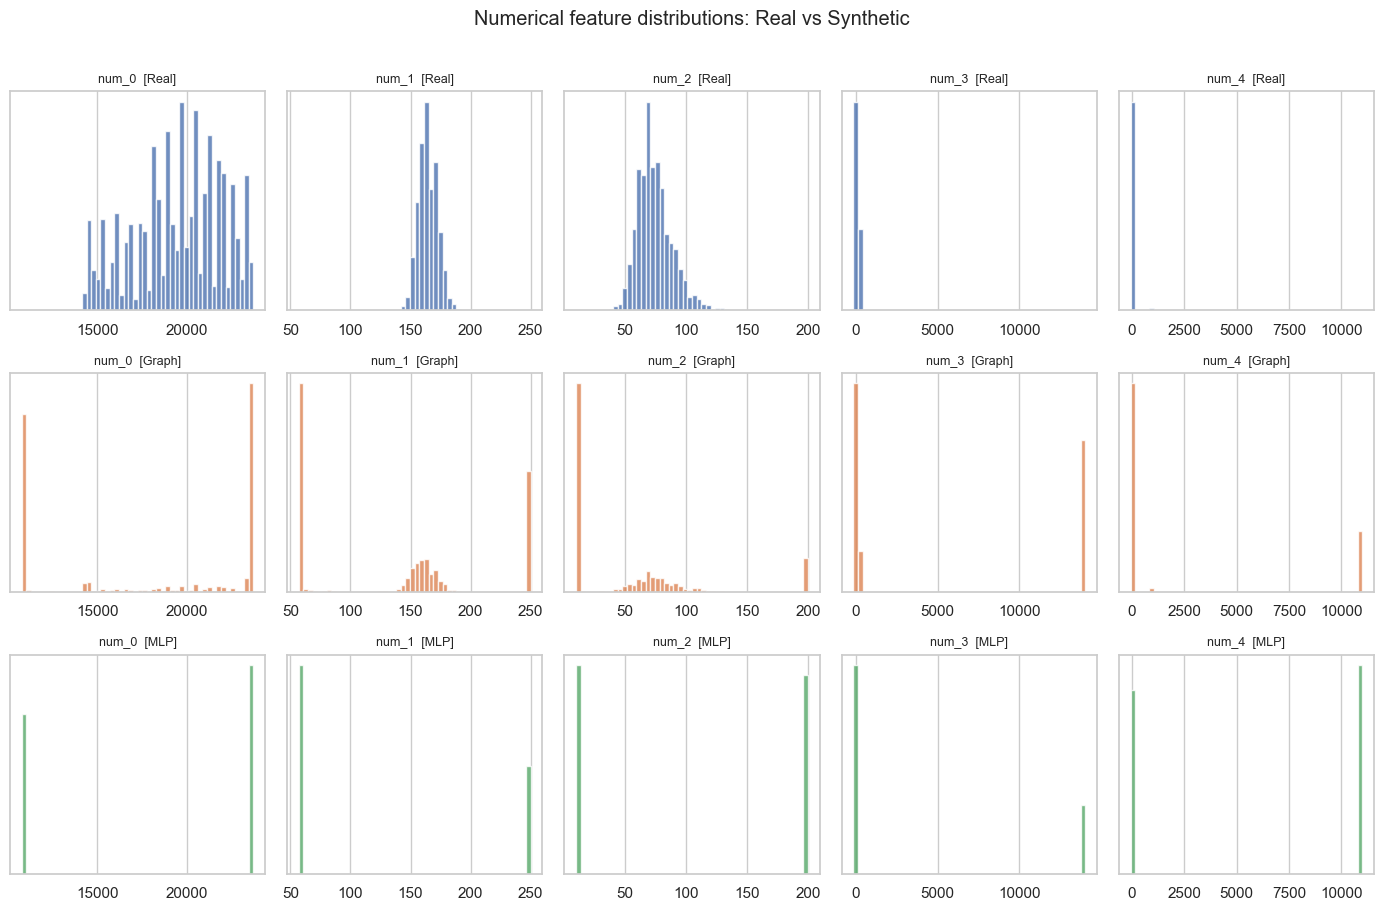

In [16]:
# Inverse-transform the numerical slice back to original scale
X_num_syn_graph_raw = dataset.num_transform.inverse_transform(
    X_syn_graph[:, :d_num_pp]
)
X_num_syn_mlp_raw = dataset.num_transform.inverse_transform(
    X_syn_mlp[:, :d_num_pp]
)

fig, axes = plt.subplots(3, D_NUM, figsize=(14, 9), sharey=False)
palette = {"Real": "#4C72B0", "Graph": "#DD8452", "MLP": "#55A868"}

for col_i in range(D_NUM):
    for row, (name, data) in enumerate([
        ("Real",  X_num_raw[:, col_i]),
        ("Graph", X_num_syn_graph_raw[:, col_i]),
        ("MLP",   X_num_syn_mlp_raw[:, col_i]),
    ]):
        ax = axes[row, col_i]
        ax.hist(data, bins=50, color=palette[name], alpha=0.8, density=True)
        ax.set_title(f"{NUM_NAMES[col_i]}  [{name}]", fontsize=9)
        ax.set_yticks([])

fig.suptitle("Numerical feature distributions: Real vs Synthetic", y=1.01)
plt.tight_layout()
plt.show()

## 11 · Evaluate: categorical fidelity

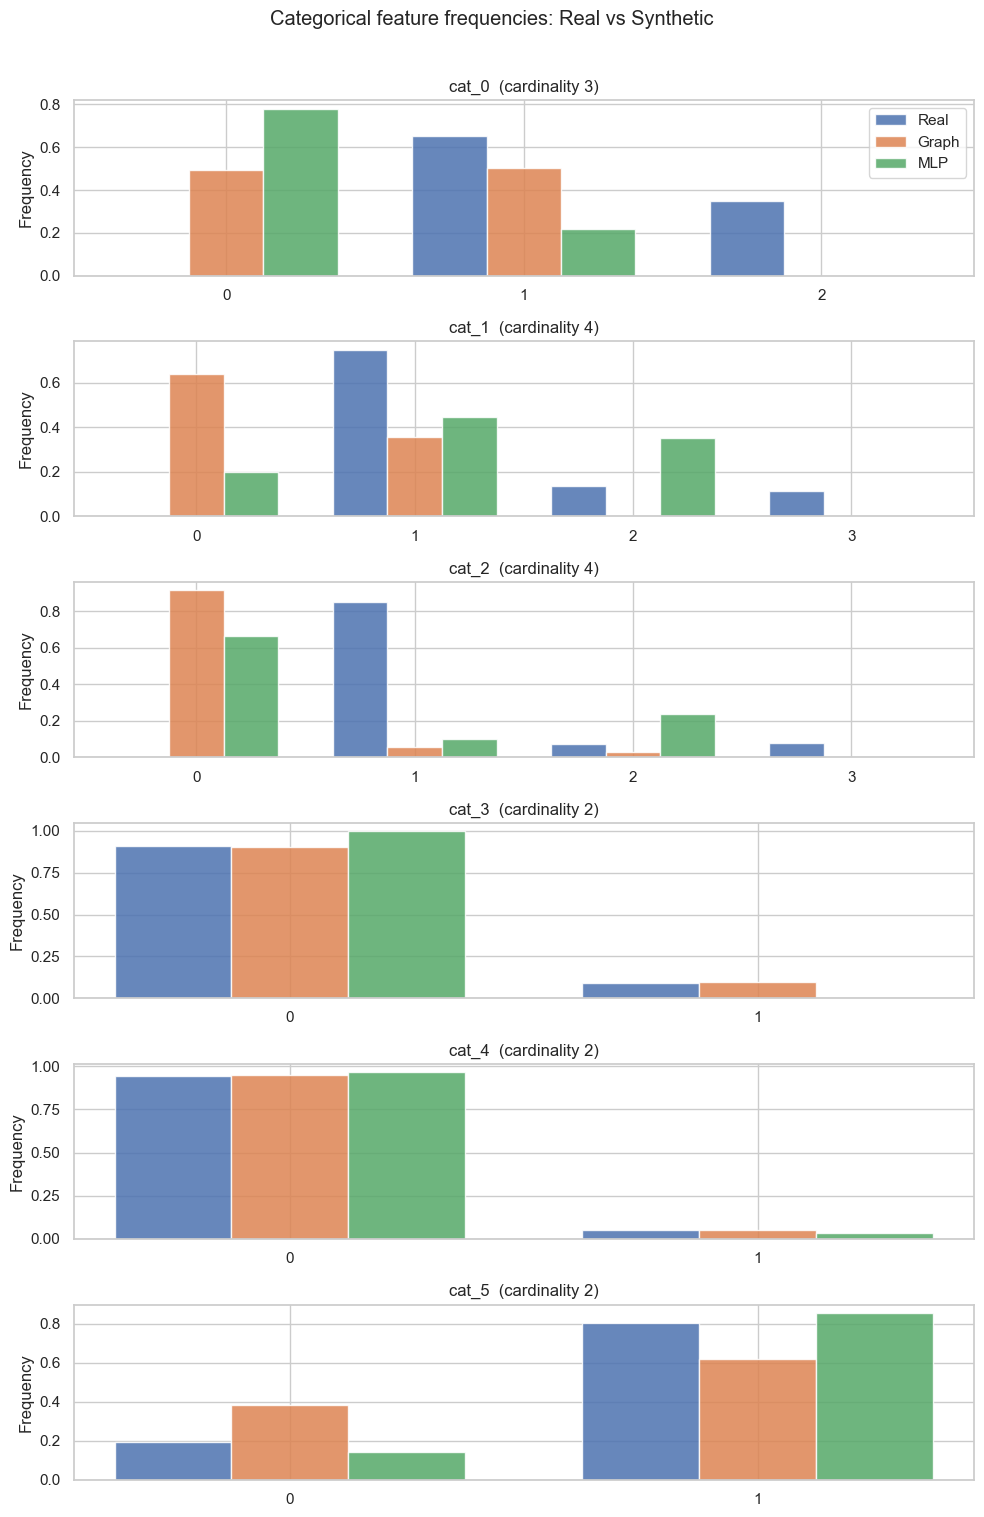

In [22]:
def extract_cat_columns(X_syn, n_cat, d_num):
    """Return integer-encoded categoricals from a synthetic batch.

    sample_all() already calls ohe_to_categories(), so each categorical
    feature occupies exactly ONE integer column in the output.
    X_syn shape: (N, d_num + n_cat).
    """
    if n_cat == 0:
        return np.empty((len(X_syn), 0), dtype=int)
    return X_syn[:, d_num : d_num + n_cat].astype(int)

X_cat_syn_graph = extract_cat_columns(X_syn_graph, N_CAT, d_num_pp)
X_cat_syn_mlp   = extract_cat_columns(X_syn_mlp,   N_CAT, d_num_pp)

fig, axes = plt.subplots(N_CAT, 1, figsize=(10, 2.5 * N_CAT))
for i in range(N_CAT):
    ax = axes[i]

    # Derive K from actual data to avoid any mismatch with cat_sizes_pp
    K = max(
        int(X_cat_raw[:, i].max())       + 1,
        int(X_cat_syn_graph[:, i].max()) + 1,
        int(X_cat_syn_mlp[:, i].max())   + 1,
    )
    cats = np.arange(K)

    real_counts  = np.bincount(X_cat_raw[:, i],       minlength=K) / len(X_cat_raw)
    graph_counts = np.bincount(X_cat_syn_graph[:, i], minlength=K) / len(X_cat_syn_graph)
    mlp_counts   = np.bincount(X_cat_syn_mlp[:, i],   minlength=K) / len(X_cat_syn_mlp)

    w = 0.25
    ax.bar(cats - w, real_counts,  width=w, label="Real",  color="#4C72B0", alpha=0.85)
    ax.bar(cats,     graph_counts, width=w, label="Graph", color="#DD8452", alpha=0.85)
    ax.bar(cats + w, mlp_counts,   width=w, label="MLP",   color="#55A868", alpha=0.85)
    ax.set_title(f"{CAT_NAMES[i]}  (cardinality {K})")
    ax.set_xticks(cats)
    ax.set_ylabel("Frequency")
    if i == 0:
        ax.legend()

fig.suptitle("Categorical feature frequencies: Real vs Synthetic", y=1.01)
plt.tight_layout()
plt.show()

## 12 · Evaluate: pairwise correlation fidelity

Compare the num–num Pearson correlation structure of real vs synthetic data.
A good generative model should preserve the correlation structure.

Correlation Frobenius error — Graph: 0.9560  |  MLP: 0.8270


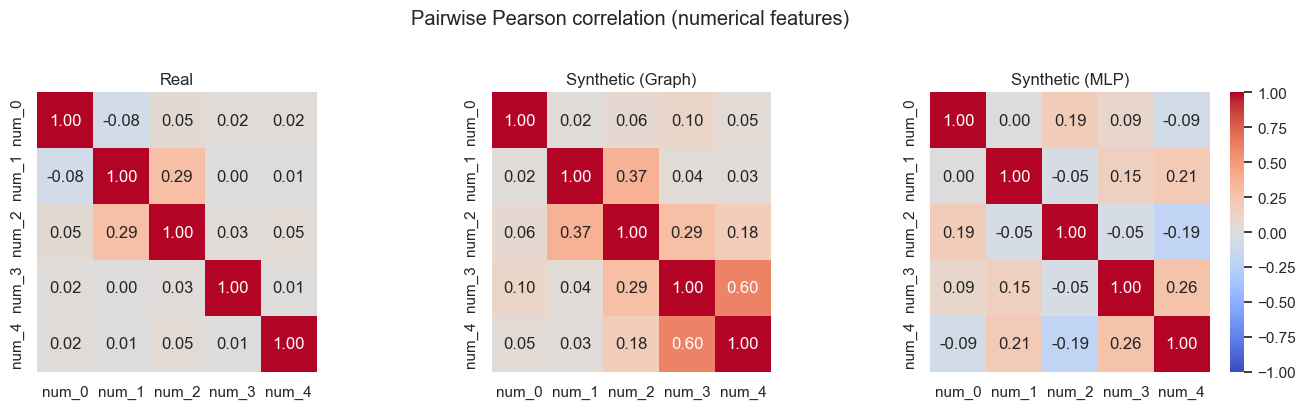

In [23]:
corr_real  = np.corrcoef(X_num_raw.T)
corr_graph = np.corrcoef(X_num_syn_graph_raw.T)
corr_mlp   = np.corrcoef(X_num_syn_mlp_raw.T)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
vmin, vmax = -1, 1

for ax, corr, title in zip(axes,
    [corr_real, corr_graph, corr_mlp],
    ["Real", "Synthetic (Graph)", "Synthetic (MLP)"]):
    sns.heatmap(corr, ax=ax, cmap="coolwarm", vmin=vmin, vmax=vmax,
                annot=True, fmt=".2f", square=True,
                xticklabels=NUM_NAMES, yticklabels=NUM_NAMES,
                cbar=(ax is axes[-1]))
    ax.set_title(title)

# Frobenius error
err_graph = float(np.linalg.norm(corr_graph - corr_real, "fro"))
err_mlp   = float(np.linalg.norm(corr_mlp   - corr_real, "fro"))
print(f"Correlation Frobenius error — Graph: {err_graph:.4f}  |  MLP: {err_mlp:.4f}")

fig.suptitle("Pairwise Pearson correlation (numerical features)", y=1.02)
plt.tight_layout()
plt.show()

## 13 · Evaluate: Train-on-Synthetic / Test-on-Real (TSTR) with CatBoost

The gold-standard downstream evaluation: train a CatBoost classifier on
synthetic data and measure accuracy on the **held-out real test set**.

In [25]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

# --- Real test set ---
X_num_test = np.load(f"{DATA_PATH}/X_num_test.npy").astype(np.float32)
X_cat_test = np.load(f"{DATA_PATH}/X_cat_test.npy").astype(np.int64)
y_test     = np.load(f"{DATA_PATH}/y_test.npy")

def to_df(X_num, X_cat):
    """Build a mixed-type DataFrame so CatBoost sees int cat columns."""
    return pd.concat([
        pd.DataFrame(X_num, columns=NUM_NAMES),
        pd.DataFrame(X_cat.astype(int), columns=CAT_NAMES),
    ], axis=1)

df_test = to_df(X_num_test, X_cat_test)

def build_train_set(X_syn, y_syn):
    X_num_s = dataset.num_transform.inverse_transform(X_syn[:, :d_num_pp])
    X_cat_s = X_syn[:, d_num_pp : d_num_pp + N_CAT].astype(int)
    return to_df(X_num_s, X_cat_s), y_syn

def tstr_score(df_train, y_train, label):
    cb = CatBoostClassifier(
        iterations=300, depth=6, learning_rate=0.05,
        cat_features=CAT_NAMES, verbose=0, random_seed=SEED
    )
    cb.fit(df_train, y_train)
    preds = cb.predict(df_test)
    proba = cb.predict_proba(df_test)[:, 1]
    acc = accuracy_score(y_test, preds)
    auc = roc_auc_score(y_test, proba)
    print(f"  [{label:20s}]  acc={acc:.4f}  AUC={auc:.4f}")
    return acc, auc

print("=== TSTR Evaluation ===")
cb_real = CatBoostClassifier(
    iterations=300, depth=6, learning_rate=0.05,
    cat_features=CAT_NAMES, verbose=0, random_seed=SEED
)
cb_real.fit(to_df(X_num_raw, X_cat_raw), y_raw)
preds_real = cb_real.predict(df_test)
proba_real = cb_real.predict_proba(df_test)[:, 1]
print(f"  [{'Real (upper bound)':20s}]  acc={accuracy_score(y_test, preds_real):.4f}"
      f"  AUC={roc_auc_score(y_test, proba_real):.4f}")

df_tr_graph, y_tr_graph = build_train_set(X_syn_graph, y_syn_graph)
df_tr_mlp,   y_tr_mlp   = build_train_set(X_syn_mlp,   y_syn_mlp)

acc_graph, auc_graph = tstr_score(df_tr_graph, y_tr_graph, "GraphAwareDenoiser")
acc_mlp,   auc_mlp   = tstr_score(df_tr_mlp,   y_tr_mlp,   "MLPDiffusion")

=== TSTR Evaluation ===
  [Real (upper bound)  ]  acc=0.7379  AUC=0.8054
  [GraphAwareDenoiser  ]  acc=0.5482  AUC=0.6833
  [MLPDiffusion        ]  acc=0.4730  AUC=0.4636


## 14 · Summary bar chart

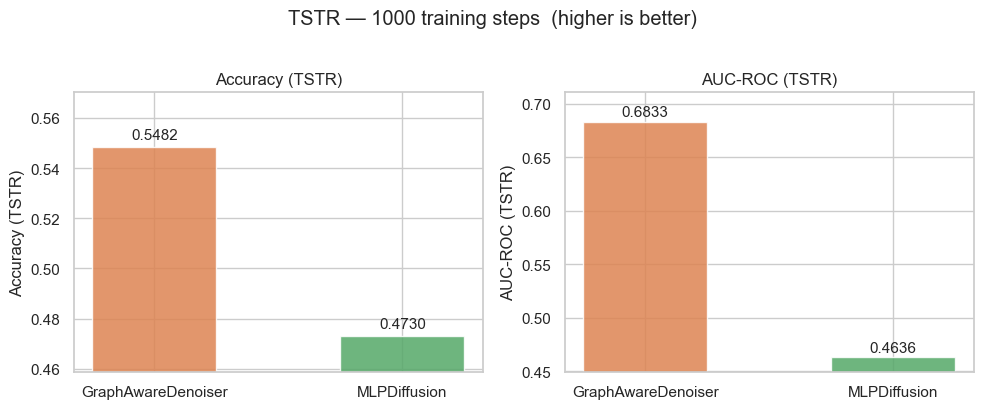

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
models = ["GraphAwareDenoiser", "MLPDiffusion"]
colors = ["#DD8452", "#55A868"]

for ax, metric, vals in zip(axes,
    ["Accuracy (TSTR)", "AUC-ROC (TSTR)"],
    [[acc_graph, acc_mlp], [auc_graph, auc_mlp]]):
    bars = ax.bar(models, vals, color=colors, alpha=0.85, edgecolor="white", width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                f"{val:.4f}", ha="center", va="bottom", fontsize=11)
    ax.set_ylim(min(vals) * 0.97, max(vals) * 1.04)
    ax.set_title(metric)
    ax.set_ylabel(metric)

fig.suptitle(f"TSTR — {STEPS} training steps  (higher is better)", y=1.02)
plt.tight_layout()
plt.show()

## 15 · Dynamic mode demo

The `dynamic` mode replaces the static precomputed adjacency with a
`DynamicAdjacency` submodule that learns a soft `(B, N, N)` matrix at every
forward pass.  Everything else — architecture, training loop, sampling — is
identical.

### When to prefer dynamic over static
| | Static | Dynamic |
|---|---|---|
| Graph structure | Fixed from data statistics | Learned end-to-end |
| Extra cost | One-time build (cheap) | Extra Q/K projections per layer |
| Best for | Clear statistical correlations | Complex, non-linear dependencies |
| Reproducibility | Fully deterministic | Depends on training random seed |

In [31]:
denoiser_dynamic = GraphAwareDenoiser(
    d_in        = d_in,
    num_classes = NUM_CLASSES,
    is_y_cond   = IS_Y_COND,
    d_num       = d_num_pp,
    cat_sizes   = cat_sizes_pp,
    graph_mode  = "dynamic",
    adjacency   = None,
    **GRAPH_PARAMS,   # contains d_model, n_layers, n_heads, top_k
).to(DEVICE)

print(f"Dynamic denoiser params: {sum(p.numel() for p in denoiser_dynamic.parameters()):,}")

print("\n=== Training GraphAwareDenoiser (dynamic mode) ===")
diffusion_dyn, ema_dyn, hist_dyn = run_training(
    denoiser_dynamic, train_loader, steps=STEPS
)

Dynamic denoiser params: 136,211

=== Training GraphAwareDenoiser (dynamic mode) ===
      Step  Progress                            M-Loss    G-Loss     Total
--------------------------------------------------------------------------
  200/1000   [██████░░░░░░░░░░░░░░░░░░░░░░░░]  20.0%    0.9583    0.5152    1.4735
  400/1000   [████████████░░░░░░░░░░░░░░░░░░]  40.0%    0.7616    0.4643    1.2259
  600/1000   [██████████████████░░░░░░░░░░░░]  60.0%    0.7625    0.4582    1.2207
  800/1000   [████████████████████████░░░░░░]  80.0%    0.7612    0.4553    1.2165
 1000/1000   [██████████████████████████████] 100.0%    0.7520    0.4517    1.2038
--------------------------------------------------------------------------
Training complete.



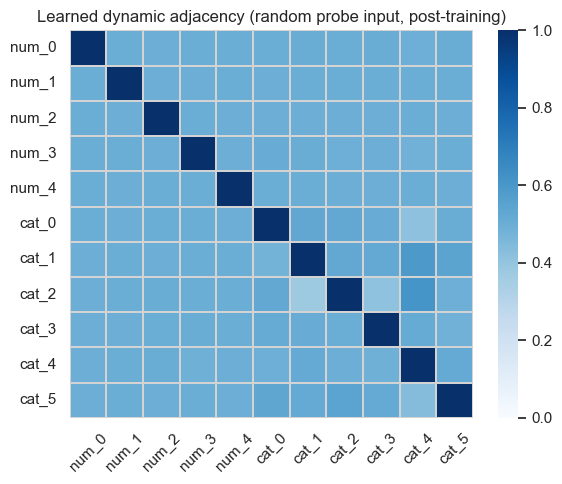

In [ ]:
# Inspect the learned adjacency on a single batch after training
denoiser_dynamic.eval()
with torch.no_grad():
    x_sample, _ = next(train_loader)
    x_sample = x_sample[:1].to(DEVICE)    # single row, B=1

    # replicate the embedding step to get node_emb
    parts = []
    if denoiser_dynamic.d_num > 0:
        xn = x_sample[:, :denoiser_dynamic.d_num].float()
        num_nodes = (xn.unsqueeze(-1) * denoiser_dynamic.num_in_weight.unsqueeze(0)
                     + denoiser_dynamic.num_in_bias.unsqueeze(0))
        parts.append(num_nodes)
    if denoiser_dynamic.n_cat > 0:
        offset = denoiser_dynamic.d_num
        cat_nodes = []
        for i, K in enumerate(denoiser_dynamic.cat_sizes):
            sl = x_sample[:, offset:offset + K].float()
            cat_nodes.append(denoiser_dynamic.cat_in_projs[i](sl))
            offset += K
        parts.append(torch.stack(cat_nodes, dim=1))
    node_emb = torch.cat(parts, dim=1)  # (1, N, d_model)

    learned_adj = denoiser_dynamic.dynamic_adj(node_emb).squeeze(0).cpu()  # (N, N)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(learned_adj.numpy(), ax=ax, cmap="Blues", vmin=0, vmax=1,
            xticklabels=NODE_NAMES, yticklabels=NODE_NAMES,
            linewidths=0.3, linecolor="lightgrey")
ax.set_title("Learned dynamic adjacency (one sample, post-training)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 16 · Save and reload a checkpoint

Demonstrates that `register_buffer` correctly persists the static adjacency
through `state_dict` — no extra handling required.

In [34]:
import tempfile, os

with tempfile.TemporaryDirectory() as tmpdir:
    ckpt_path = os.path.join(tmpdir, "model.pt")

    # Save (EMA weights include the buffer)
    torch.save(ema_graph.state_dict(), ckpt_path)

    # Reconstruct the model (same constructor args, adjacency can be None —
    # the buffer will be overwritten by load_state_dict)
    model_reload = GraphAwareDenoiser(
        d_in=d_in, num_classes=NUM_CLASSES, is_y_cond=IS_Y_COND,
        d_num=d_num_pp, cat_sizes=cat_sizes_pp,
        graph_mode="static", adjacency=None,   # placeholder buffer
        **GRAPH_PARAMS,
    )
    model_reload.load_state_dict(torch.load(ckpt_path, map_location="cpu"))

    # Verify the adjacency was restored
    assert torch.equal(model_reload.static_adj, adj_train), "Adjacency mismatch after reload!"
    print("Checkpoint save/reload: adjacency correctly restored from state_dict ✓")

    # Verify outputs match
    model_reload.eval()
    ema_graph.eval()
    x_test_batch = torch.randn(4, d_in)
    t_test = torch.randint(0, 1000, (4,))
    with torch.no_grad():
        out_original = ema_graph(x_test_batch, t_test)
        out_reloaded = model_reload(x_test_batch, t_test)
    assert torch.allclose(out_original, out_reloaded, atol=1e-5), "Output mismatch!"
    print("Forward pass outputs match after reload ✓")

Checkpoint save/reload: adjacency correctly restored from state_dict ✓
Forward pass outputs match after reload ✓


## 17 · Using the pipeline script instead

Everything above can also be driven from the command line using the existing
`pipeline.py` entry point.  The notebook is equivalent to running:

```bash
# Train
python scripts/pipeline.py --config exp/cardio/config_graph.toml --train

# Sample
python scripts/pipeline.py --config exp/cardio/config_graph.toml --sample

# Evaluate
python scripts/pipeline.py --config exp/cardio/config_graph.toml --eval

# All three in one go
python scripts/pipeline.py --config exp/cardio/config_graph.toml --train --sample --eval
```

Key config knobs:

| Key | Effect |
|---|---|
| `model.graph.enabled = false` | Falls back to vanilla `MLPDiffusion` |
| `model.graph.mode = "dynamic"` | Switches to learned adjacency |
| `model.graph.threshold` | Edge inclusion threshold (static only) |
| `model.graph.n_layers` / `d_model` / `n_heads` | Architecture size |
| `model.graph.sparsity_top_k` | Top-k neighbour limit (dynamic only) |